# Tea Leaf Disease Classification Using Transfer Learning: A Comparative Study of VGG16 and ResNet50

In [80]:
import os
import random
import zipfile
import shutil
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from PIL import Image
from collections import Counter

In [81]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Set reproducibility

In [82]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

In [83]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

Using device: cpu


Extract Dataset

In [84]:
ZIP_PATH = 'Data_A2-20260417T152750Z-3-001.zip'
EXTRACT_DIR = 'dataset'
DATA_DIR = os.path.join(EXTRACT_DIR, 'Data_A2')

In [85]:
classes = sorted(os.listdir(DATA_DIR))
classes

['algal leaf', 'brown blight', 'white spot']

In [86]:
#count images inside the folders
for cls in classes:
    cls_path = os.path.join(DATA_DIR, cls)
    count = len([f for f in os.listdir(cls_path) if f.lower().endswith('.jpg')])
    print(f'  {cls}: {count} images')

  algal leaf: 113 images
  brown blight: 113 images
  white spot: 142 images


The dataset relatively balanced across 3 classes.White spot category contains slightly more samples.It may contribute slightly better performance for the white spot class during training and evaluation.

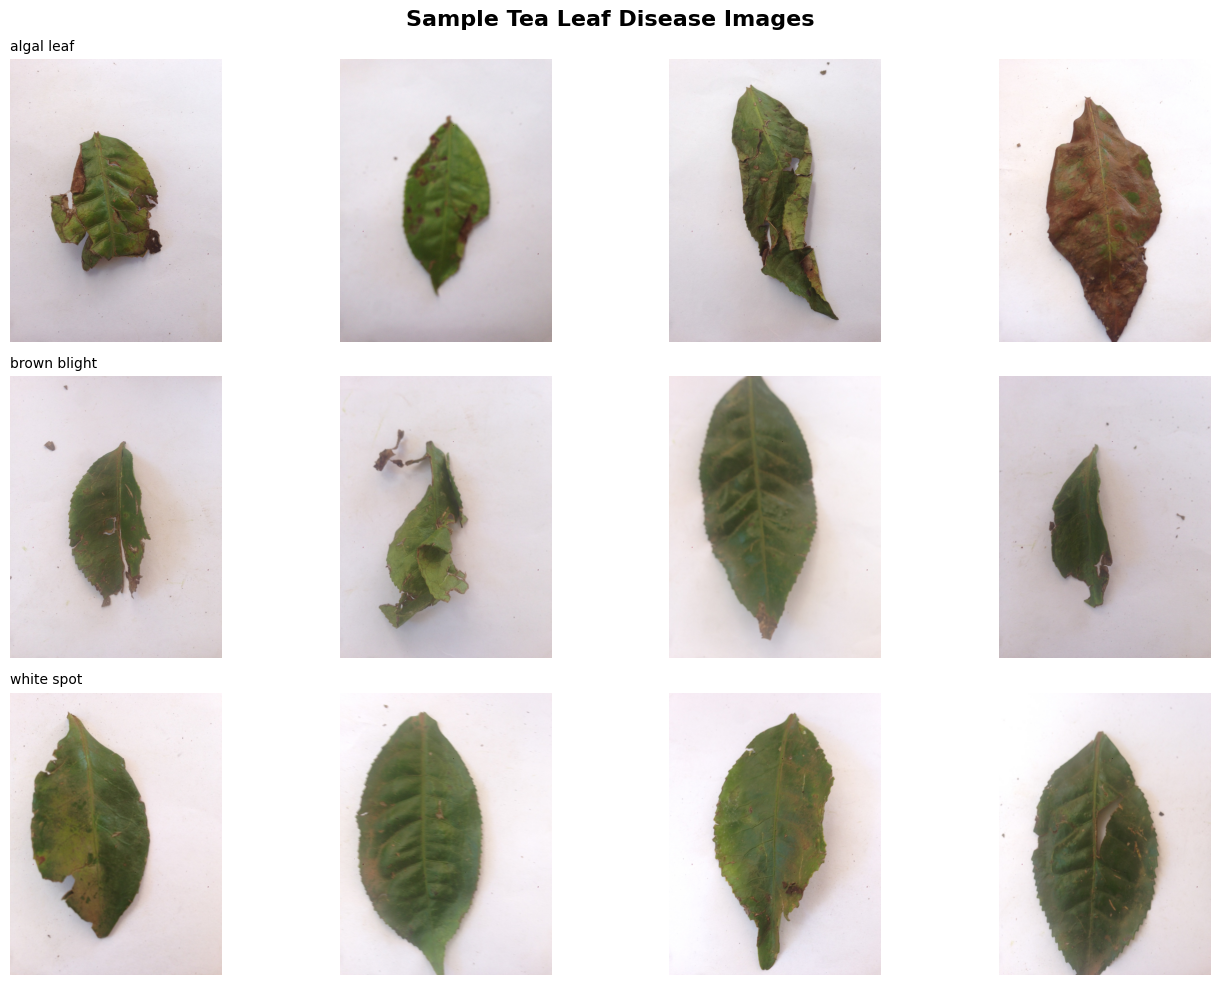

Saved: sample_images.png


In [87]:
fig, axes = plt.subplots(3, 4, figsize=(14, 10))
fig.suptitle('Sample Tea Leaf Disease Images', fontsize=16, fontweight='bold')

for row, cls in enumerate(classes):
    cls_path = os.path.join(DATA_DIR, cls)
    images = [f for f in os.listdir(cls_path) if f.lower().endswith('.jpg')]
    sampled = random.sample(images, min(4, len(images)))
    for col, img_name in enumerate(sampled):
        img = Image.open(os.path.join(cls_path, img_name))
        axes[row, col].imshow(img)
        axes[row, col].set_title(cls if col == 0 else '', fontsize=10, loc='left')
        axes[row, col].axis('off')

plt.tight_layout()
plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: sample_images.png')

# Pre Processing

In [88]:
IMG_SIZE   = 224
BATCH_SIZE = 16

# ImageNet mean/std for normalisation
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

In [89]:
#Train set transformation
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD),
])
#Only train data should be augmented

In [90]:
#val and test set transformation
val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD),
])

In [91]:
#Load dataset
full_dataset = datasets.ImageFolder(root=DATA_DIR, transform=train_transform)
CLASS_NAMES  = full_dataset.classes
NUM_CLASSES  = len(CLASS_NAMES)

In [92]:
print(full_dataset.class_to_idx)

{'algal leaf': 0, 'brown blight': 1, 'white spot': 2}


In [93]:
len(full_dataset)

368

In [94]:
#train,val,test split(70 / 15 / 15 )
n_total = len(full_dataset)
n_train = int(0.70 * n_total)
n_val   = int(0.15 * n_total)
n_test  = n_total - n_train - n_val

In [95]:
print(f'Train: {n_train}, Val: {n_val}, Test: {n_test}')

Train: 257, Val: 55, Test: 56


In [96]:
#Random split
train_set, val_set, test_set = random_split(
    full_dataset, [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(SEED)
)

In [97]:
# Override transforms for val / test
val_set.dataset  = datasets.ImageFolder(root=DATA_DIR, transform=val_test_transform)
test_set.dataset = datasets.ImageFolder(root=DATA_DIR, transform=val_test_transform)


In [98]:
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_set,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_set,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# Build VGG16 model

In [99]:
#Load pretrained VGG model
model_vgg16=models.vgg16(
    weights=models.VGG16_Weights.IMAGENET1K_V1
)

In [100]:
#Freeze feature extraction layer
for param in model_vgg16.features.parameters():
    param.requires_grad=False

In [101]:
#Replace last classification layer
in_features = model_vgg16.classifier[-1].in_features
model_vgg16.classifier[-1] = nn.Linear(in_features, NUM_CLASSES)

In [102]:
#Check number of trainable parameters
trainable = sum(p.numel() for p in model_vgg16.parameters() if p.requires_grad)
total = sum(p.numel() for p in model_vgg16.parameters())

print(f'VGG16 — trainable params: {trainable:,} / {total:,}')

VGG16 — trainable params: 119,558,147 / 134,272,835


# Build ResNet50 Model

In [103]:
#Load pretrained ResNet50 model
model_resnet50=models.resnet50(
    weights=models.ResNet50_Weights.IMAGENET1K_V2
)

In [104]:
#Freeze earlier layers except the last block
for name, param in model_resnet50.named_parameters():
    if not name.startswith('layer4') and not name.startswith('fc'):
        param.requires_grad = False

In [105]:
#Replace final classification layer
in_features = model_resnet50.fc.in_features
model_resnet50.fc = nn.Linear(in_features,NUM_CLASSES)

In [106]:
trainable = sum(p.numel() for p in model_resnet50.parameters() if p.requires_grad)
total = sum(p.numel() for p in model_resnet50.parameters())

print(f'ResNet50 — trainable params: {trainable:,} / {total:,}')

ResNet50 — trainable params: 14,970,883 / 23,514,179


In [107]:
model_vgg16 = model_vgg16.to(DEVICE)
model_resnet50 = model_resnet50.to(DEVICE)

In [108]:
#Define loss function
criterion = nn.CrossEntropyLoss()

In [109]:
#Define optimizers
optimizer_vgg16 = optim.Adam(
    filter(lambda p: p.requires_grad, model_vgg16.parameters()),
    lr=0.0001
)

optimizer_resnet50 = optim.Adam(
    filter(lambda p: p.requires_grad, model_resnet50.parameters()),
    lr=0.0001
)

In [110]:
#Training function
def train_model(model, train_loader, val_loader, optimizer, epochs=10, patience=3):

    train_losses = []
    val_losses = []
    train_accs = []
    val_accs = []

    best_val_loss = float('inf')
    patience_counter = 0

    for epoch in range(epochs):

        ### TRAINING
        model.train()
        running_loss = 0
        correct = 0
        total = 0

        for images, labels in train_loader:

            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_acc = correct / total

        ### VALIDATION
        model.eval()
        val_loss = 0
        correct = 0
        total = 0

        with torch.no_grad():
            for images, labels in val_loader:

                images = images.to(DEVICE)
                labels = labels.to(DEVICE)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item()

                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        val_acc = correct / total

        train_losses.append(running_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)

        print(f"\nEpoch {epoch+1}")
        print(f"Train Loss: {running_loss:.4f} | Train Acc: {train_acc:.4f}")
        print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

        # EARLY STOPPING 
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0

            # Save best model
            torch.save(model.state_dict(), "best_model.pth")
            print("Best model saved")

        else:
            patience_counter += 1
            print(f"No improvement ({patience_counter}/{patience})")

            if patience_counter >= patience:
                print("Early stopping triggered")
                break

    return train_losses, val_losses, train_accs, val_accs

## Train VGG16

In [111]:
vgg_train_loss, vgg_val_loss, vgg_train_acc, vgg_val_acc = train_model(
    model_vgg16,
    train_loader,
    val_loader,
    optimizer_vgg16,
    epochs=20,
    patience=3
)


Epoch 1
Train Loss: 17.6634 | Train Acc: 0.4202
Val Loss: 3.4243 | Val Acc: 0.6727
Best model saved

Epoch 2
Train Loss: 15.3519 | Train Acc: 0.5409
Val Loss: 3.5606 | Val Acc: 0.5636
No improvement (1/3)

Epoch 3
Train Loss: 15.9169 | Train Acc: 0.5642
Val Loss: 3.5473 | Val Acc: 0.5818
No improvement (2/3)

Epoch 4
Train Loss: 13.9330 | Train Acc: 0.6265
Val Loss: 3.1887 | Val Acc: 0.7091
Best model saved

Epoch 5
Train Loss: 12.4192 | Train Acc: 0.6926
Val Loss: 2.5084 | Val Acc: 0.7455
Best model saved

Epoch 6
Train Loss: 14.2814 | Train Acc: 0.6187
Val Loss: 2.2613 | Val Acc: 0.8182
Best model saved

Epoch 7
Train Loss: 11.5790 | Train Acc: 0.7043
Val Loss: 2.4354 | Val Acc: 0.7636
No improvement (1/3)

Epoch 8
Train Loss: 12.4132 | Train Acc: 0.6926
Val Loss: 2.6383 | Val Acc: 0.7636
No improvement (2/3)

Epoch 9
Train Loss: 10.6965 | Train Acc: 0.7704
Val Loss: 2.5048 | Val Acc: 0.7818
No improvement (3/3)
Early stopping triggered


Here, validation Accuracy > training Accuracy. Also, validation accuracy gives a slightly high value(0.7818). This indicates that the model is not overfitting. That means a strong regularization effect from augmentation.

## Train ResNet50

In [112]:
resnet_train_loss, resnet_val_loss, resnet_train_acc, resnet_val_acc = train_model(
    model_resnet50,
    train_loader,
    val_loader,
    optimizer_resnet50,
    epochs=20,
    patience=3
)


Epoch 1
Train Loss: 18.5868 | Train Acc: 0.4047
Val Loss: 4.2404 | Val Acc: 0.4545
Best model saved

Epoch 2
Train Loss: 16.5357 | Train Acc: 0.6809
Val Loss: 3.7168 | Val Acc: 0.6182
Best model saved

Epoch 3
Train Loss: 13.6204 | Train Acc: 0.7160
Val Loss: 3.3188 | Val Acc: 0.6364
Best model saved

Epoch 4
Train Loss: 10.6625 | Train Acc: 0.7821
Val Loss: 2.7772 | Val Acc: 0.7455
Best model saved

Epoch 5
Train Loss: 7.9704 | Train Acc: 0.8366
Val Loss: 2.5607 | Val Acc: 0.7636
Best model saved

Epoch 6
Train Loss: 7.7693 | Train Acc: 0.8638
Val Loss: 2.2790 | Val Acc: 0.7455
Best model saved

Epoch 7
Train Loss: 4.8231 | Train Acc: 0.9183
Val Loss: 2.3578 | Val Acc: 0.7636
No improvement (1/3)

Epoch 8
Train Loss: 4.1103 | Train Acc: 0.9339
Val Loss: 2.3567 | Val Acc: 0.8000
No improvement (2/3)

Epoch 9
Train Loss: 4.6453 | Train Acc: 0.9300
Val Loss: 2.2310 | Val Acc: 0.7636
Best model saved

Epoch 10
Train Loss: 3.2496 | Train Acc: 0.9455
Val Loss: 2.1254 | Val Acc: 0.8364
Best

In the ResNet model, Validation accuracy < Training accuracy. That means there may be slightly overfitting. This can happen because of the small dataset.

In [113]:
#Test accuracy function
def evaluate_model(model, test_loader):

    model.eval()

    correct = 0
    total = 0

    y_true = []
    y_pred = []

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(DEVICE)

            outputs = model(images)

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted.cpu() == labels).sum().item()

            y_true.extend(labels.numpy())
            y_pred.extend(predicted.cpu().numpy())

    accuracy = correct / total

    return accuracy, y_true, y_pred

## Evaluate VGG16

In [114]:
vgg_acc, y_true_vgg, y_pred_vgg = evaluate_model(
    model_vgg16,
    test_loader
)

print("VGG16 Test Accuracy:", vgg_acc)

VGG16 Test Accuracy: 0.8571428571428571


VGG16 gives an accuracy of about 85.71%. This means strong performance for the 3 class small dataset.

In [121]:
#Classification report VGG16
print(classification_report(
    y_true_vgg,
    y_pred_vgg,
    target_names=CLASS_NAMES
))

              precision    recall  f1-score   support

  algal leaf       0.92      0.80      0.86        15
brown blight       0.78      0.88      0.82        16
  white spot       0.88      0.88      0.88        25

    accuracy                           0.86        56
   macro avg       0.86      0.85      0.85        56
weighted avg       0.86      0.86      0.86        56



By looking the recall we can conclude that the model- VGG16 detects white spots best and the brown blight hardest.because the similar texture to algal leaf.

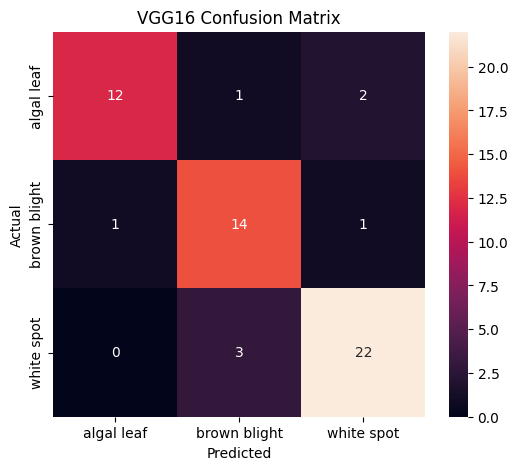

In [122]:
#VGG16 confusion matrix
plt.figure(figsize=(6,5))

sns.heatmap(
    confusion_matrix(y_true_vgg, y_pred_vgg),
    annot=True,
    fmt='d',
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("VGG16 Confusion Matrix")

plt.savefig("vgg16_confusion_matrix.png", dpi=300)

plt.show()

Better diagonal concentration, which means better classification consistency.

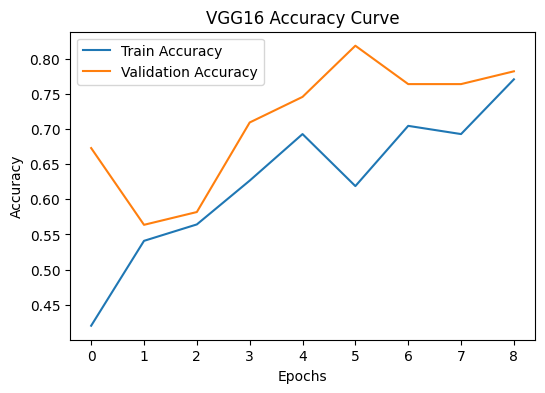

In [123]:
#Accuracy curve VGG
plt.figure(figsize=(6,4))

plt.plot(vgg_train_acc, label="Train Accuracy")
plt.plot(vgg_val_acc, label="Validation Accuracy")

plt.title("VGG16 Accuracy Curve")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

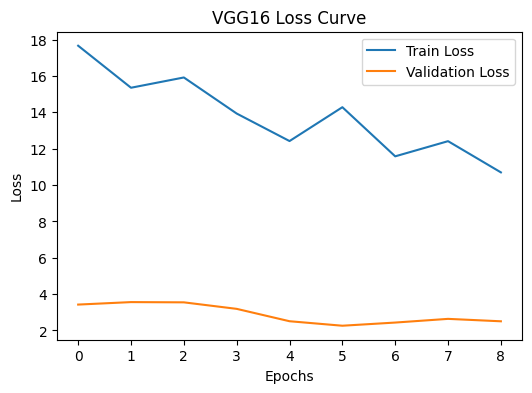

In [124]:
#Loss Curve
plt.figure(figsize=(6,4))

plt.plot(vgg_train_loss, label="Train Loss")
plt.plot(vgg_val_loss, label="Validation Loss")

plt.title("VGG16 Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.show()

## Evaluate ResNet50

In [125]:
resnet_acc, y_true_resnet, y_pred_resnet = evaluate_model(
    model_resnet50,
    test_loader
)

print("ResNet50 Test Accuracy:", resnet_acc)

C:\Users\Nuwani Hitibandara\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\utils\data\dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


ResNet50 Test Accuracy: 0.8392857142857143


The ResNet accuracy(83.92%) is slightly lower than that of VGG16. This can happen because the VGG16 model performs better for small datasets than the ResNet50 model.


In [126]:
#classification report ResNet50
print(classification_report(
    y_true_resnet,
    y_pred_resnet,
    target_names=CLASS_NAMES
))

              precision    recall  f1-score   support

  algal leaf       1.00      0.93      0.97        15
brown blight       0.72      0.81      0.76        16
  white spot       0.83      0.80      0.82        25

    accuracy                           0.84        56
   macro avg       0.85      0.85      0.85        56
weighted avg       0.85      0.84      0.84        56



By looking at the recall values ResNet struggled to recognize  white spot. The reason can be an insufficient dataset size for deeper feature adaptation

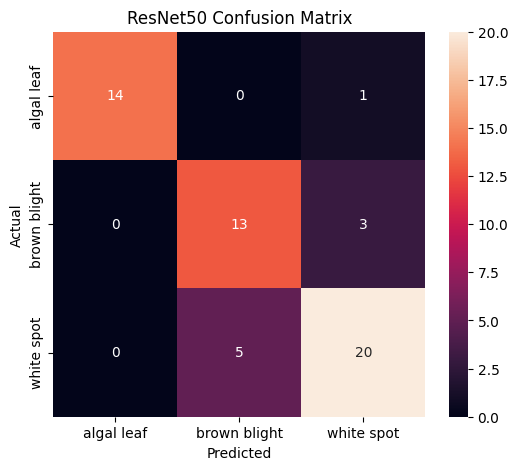

In [127]:
#ResNet50 confusion matrix
plt.figure(figsize=(6,5))

sns.heatmap(
    confusion_matrix(y_true_resnet, y_pred_resnet),
    annot=True,
    fmt='d',
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("ResNet50 Confusion Matrix")

plt.savefig("resnet50_confusion_matrix.png", dpi=300)

plt.show()

more off diagonal errors than VGG model.thus more confution between disease types

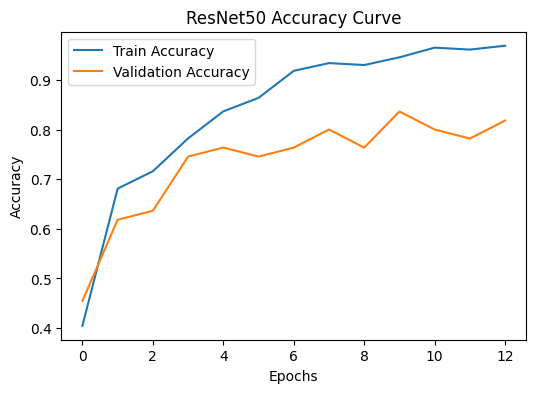

In [128]:
#Accuracy curve ResNet
plt.figure(figsize=(6,4))

plt.plot(resnet_train_acc, label="Train Accuracy")
plt.plot(resnet_val_acc, label="Validation Accuracy")

plt.title("ResNet50 Accuracy Curve")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

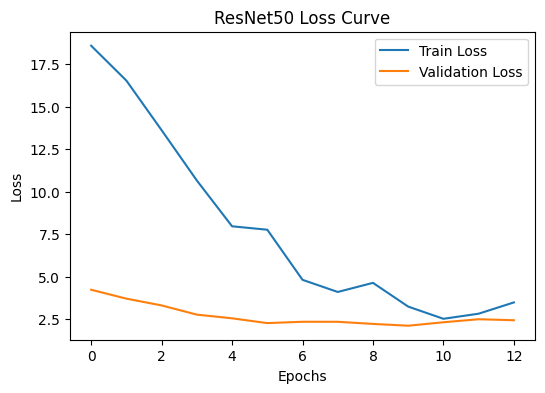

In [129]:
#Loss Curve
plt.figure(figsize=(6,4))

plt.plot(resnet_train_loss, label="Train Loss")
plt.plot(resnet_val_loss, label="Validation Loss")

plt.title("ResNet50 Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.show()

## Accuracy Comparison plot

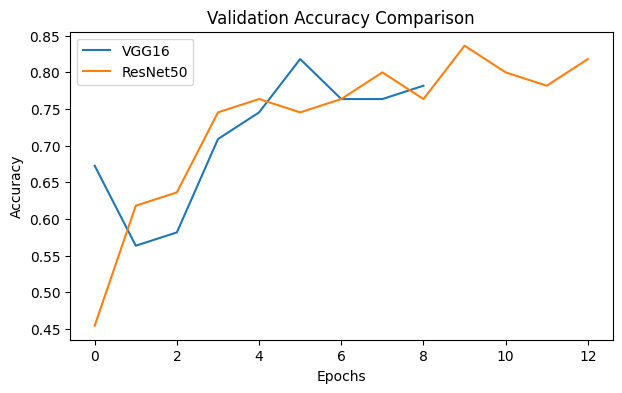

In [130]:
plt.figure(figsize=(7,4))
plt.plot(vgg_val_acc, label="VGG16")
plt.plot(resnet_val_acc, label="ResNet50")
plt.title("Validation Accuracy Comparison")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.savefig("vgg_resnet_accuracy.png", dpi=300)
plt.show()

After about 8 epochs, VGG16 validation accuracy > ResNet50 validation accuracy. So, for tea leaf disease classification, VGG performs better than ResNet in a transfer learning setup. The reason can be that the ResNet starts overfitting after 8 epochs.

## Loss Comparison plot

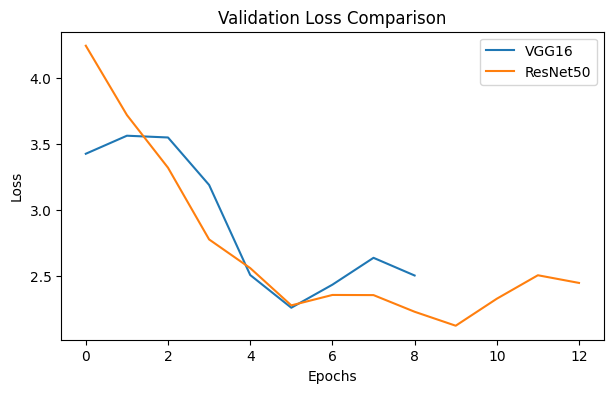

In [131]:
plt.figure(figsize=(7,4))
plt.plot(vgg_val_loss, label="VGG16")
plt.plot(resnet_val_loss, label="ResNet50")
plt.title("Validation Loss Comparison")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.savefig("vgg_resnet_loss.png", dpi=300)
plt.show()

VGG gives a lower validation loss after about 5 epochs than ResNet. This means the VGG model is better convergent and has better generalization ability.

## Save Models

In [132]:
torch.save(model_vgg16.state_dict(), "vgg16_leaf_model.pth")

torch.save(model_resnet50.state_dict(), "resnet50_leaf_model.pth")